# Phase 11 — MLflow Experiment Report
**DS11 Hybrid Recommender System**

Loads all 9 MLflow runs, builds a param comparison table, split metric
leaderboards (Recommender vs NLP), artifact registry, inline artifact
display, bar charts, and exports to HTML.

---

### Run order required before this notebook

| Step | File | Runs logged |
|------|------|-------------|
| 1 | `03_sentiment_nlp.py` | `SVM` |
| 2 | `03_b_t5_summarization.py` | `T5_summary` |
| 3 | `05_content_cf.ipynb` | `content_only`, `cf_item_item` |
| 4 | `06_mf_ncf.ipynb` | `MF`, `NCF` |
| 5 | `09_als_svdpp.ipynb` | `ALS`, `SVDpp` |
| 6 | `08_hybrid.ipynb` | `Hybrid` |

All files must use:
```python
mlflow.set_tracking_uri('mlflow/')
mlflow.set_experiment('DS11')
```

### Important notes

- **Notebook CWD is `src/`** — MLflow store is one level up at `../mlflow/`.
  Upstream `.py` files run from the project root and write to `<root>/mlflow/`.
  `MLFLOW_URI = '../mlflow/'` resolves to the same location from `src/`.
- **Artifacts live in both `mlruns/` and `outputs/`** — `mlflow.log_artifact()`
  copies files into the mlruns store. The registry in 11.4 checks both
  locations and shows which is present.
- **Pathlib throughout** — all path construction uses `pathlib.Path` to avoid
  mixed forward/backslash issues on Windows.
- **Duplicate run deduplication** — if a run name appears multiple times
  (e.g. from re-runs), only the latest FINISHED run is kept.


## 11.0 — Setup & Imports

In [11]:
import os
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from IPython.display import display, Image
from pathlib import Path

# --- Paths -------------------------------------------------------------------
# Notebook runs from  <root>/src/   =>  PROJECT_ROOT = <root>
PROJECT_ROOT = Path(os.getcwd()).parent
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Upstream files all run from PROJECT_ROOT and use mlflow.set_tracking_uri('mlflow/')
# From src/ that resolves to <root>/mlflow/ -- so we use '../mlflow/' here.
MLFLOW_URI      = '../mlflow/'
EXPERIMENT_NAME = 'DS11'

mlflow.set_tracking_uri(MLFLOW_URI)

print(f'CWD              : {os.getcwd()}')
print(f'PROJECT_ROOT     : {PROJECT_ROOT}')
print(f'OUTPUTS_DIR      : {OUTPUTS_DIR}')
print(f'MODELS_DIR       : {MODELS_DIR}')
print(f'MLflow URI       : {mlflow.get_tracking_uri()}')
print(f'Resolved mlruns  : {(Path(MLFLOW_URI) / "mlruns").resolve()}')

# --- Run name registry -------------------------------------------------------
NLP_RUNS         = ['SVM', 'T5_summary']
RECOMMENDER_RUNS = ['content_only', 'cf_item_item', 'MF', 'NCF', 'ALS', 'SVDpp', 'Hybrid']
ALL_RUNS         = NLP_RUNS + RECOMMENDER_RUNS

print(f'\nNLP runs         ({len(NLP_RUNS)}): {NLP_RUNS}')
print(f'Recommender runs ({len(RECOMMENDER_RUNS)}): {RECOMMENDER_RUNS}')
print(f'Total expected   ({len(ALL_RUNS)}): {ALL_RUNS}')


CWD              : e:\rs\src
PROJECT_ROOT     : e:\rs
OUTPUTS_DIR      : e:\rs\outputs
MODELS_DIR       : e:\rs\models
MLflow URI       : ../mlflow/
Resolved mlruns  : E:\rs\mlflow\mlruns

NLP runs         (2): ['SVM', 'T5_summary']
Recommender runs (7): ['content_only', 'cf_item_item', 'MF', 'NCF', 'ALS', 'SVDpp', 'Hybrid']
Total expected   (9): ['SVM', 'T5_summary', 'content_only', 'cf_item_item', 'MF', 'NCF', 'ALS', 'SVDpp', 'Hybrid']


## 11.1 — Load All 9 Runs

In [12]:
# --- Load all runs from DS11 experiment ------------------------------------
try:
    runs_df = mlflow.search_runs(
        experiment_names=[EXPERIMENT_NAME],
        order_by=['start_time DESC']
    )
except Exception as e:
    raise RuntimeError(
        f'Could not load MLflow runs.\n'
        f'Ensure all upstream files ran with mlflow.set_tracking_uri(\'mlflow/\')\n'
        f'from the project root, not from src/.\n'
        f'Original error: {e}'
    )

print(f'Total runs found : {len(runs_df)}')

# --- Resolve run name column (varies by MLflow version) --------------------
RUN_NAME_COL = None
for candidate in ['tags.mlflow.runName', 'run_name', 'tags.run_name']:
    if candidate in runs_df.columns:
        RUN_NAME_COL = candidate
        break

if RUN_NAME_COL is None:
    raise KeyError(f'Cannot find run name column. Available: {runs_df.columns.tolist()}')

print(f'Run name column  : {RUN_NAME_COL!r}')

# --- Validate ---------------------------------------------------------------
found_run_names = set(runs_df[RUN_NAME_COL].dropna())
missing_runs    = [r for r in ALL_RUNS if r not in found_run_names]
extra_runs      = [r for r in found_run_names if r not in ALL_RUNS]

if missing_runs:
    print(f'\n WARNING -- Missing runs : {missing_runs}')
    print('   Run the corresponding upstream files first.')
else:
    print(f'\n OK -- All {len(ALL_RUNS)} expected runs present.')

if extra_runs:
    print(f' INFO -- Extra runs (will be ignored): {extra_runs}')

print(f'\nRun names found  : {sorted(found_run_names)}')
runs_df[[RUN_NAME_COL, 'status', 'start_time', 'end_time']].head(15)


Total runs found : 103
Run name column  : 'tags.mlflow.runName'

 OK -- All 9 expected runs present.
 INFO -- Extra runs (will be ignored): ['phase1_data_ingestion']

Run names found  : ['ALS', 'Hybrid', 'MF', 'NCF', 'SVDpp', 'SVM', 'T5_summary', 'cf_item_item', 'content_only', 'phase1_data_ingestion']


,tags.mlflow.runName,status,start_time,end_time
0,Hybrid,FINISHED,2026-03-23 23:45:46.492000+00:00,2026-03-23 23:45:46.718000+00:00
1,SVDpp,FINISHED,2026-03-23 23:45:30.393000+00:00,2026-03-23 23:45:30.598000+00:00
2,ALS,FINISHED,2026-03-23 23:45:25.210000+00:00,2026-03-23 23:45:25.315000+00:00
3,cf_item_item,FINISHED,2026-03-23 23:32:43.675000+00:00,2026-03-23 23:32:43.711000+00:00
4,content_only,FINISHED,2026-03-23 23:32:43.635000+00:00,2026-03-23 23:32:43.671000+00:00
5,phase1_data_ingestion,FINISHED,2026-03-23 23:30:42.922000+00:00,2026-03-23 23:31:06.927000+00:00
6,Hybrid,FINISHED,2026-03-23 23:05:57.774000+00:00,2026-03-23 23:05:58.042000+00:00
7,NCF,FINISHED,2026-03-23 23:03:33.098000+00:00,2026-03-23 23:05:40.298000+00:00
8,MF,FINISHED,2026-03-23 23:02:30.837000+00:00,2026-03-23 23:03:33.040000+00:00
9,SVDpp,FINISHED,2026-03-22 20:10:51.631000+00:00,2026-03-22 20:10:51.784000+00:00


In [13]:
# --- Keep only the LATEST FINISHED run per run_name ------------------------
# Handles the common case where a training file was re-run multiple times.
runs_df = runs_df[runs_df['status'] == 'FINISHED'].copy()
runs_df = (
    runs_df
    .sort_values('start_time', ascending=False)
    .drop_duplicates(subset=[RUN_NAME_COL], keep='first')
    .reset_index(drop=True)
)
runs_df['run_name'] = runs_df[RUN_NAME_COL]

# Filter to the 9 expected runs only -- drop anything unrecognised
runs_df = runs_df[runs_df['run_name'].isin(ALL_RUNS)].reset_index(drop=True)

print(f'Unique finished runs kept: {len(runs_df)}')
print(runs_df[['run_name', 'run_id', 'start_time']].to_string(index=False))


Unique finished runs kept: 9
    run_name                           run_id                       start_time
      Hybrid 4692aed79b7a4d26aa83671db104d022 2026-03-23 23:45:46.492000+00:00
       SVDpp 86b25db8ce334d8199979f9c713f504a 2026-03-23 23:45:30.393000+00:00
         ALS 24e23ca1ef9b449bb5bcdc5aeb5ca239 2026-03-23 23:45:25.210000+00:00
cf_item_item c43f06546bf343c495302944a53145e6 2026-03-23 23:32:43.675000+00:00
content_only 6eaf83caaa804bff8e109172695c1bf6 2026-03-23 23:32:43.635000+00:00
         NCF 44cea7fbf73c4dc5ac1a935eed1a5dad 2026-03-23 23:03:33.098000+00:00
          MF 5ad1f602b628497daf237a82d0c17ccd 2026-03-23 23:02:30.837000+00:00
  T5_summary f61d47d52c464f9e9defac9815f6b79a 2026-03-22 19:37:22.015000+00:00
         SVM b00727ee1ad749b392e340a6043d044d 2026-03-22 19:28:29.982000+00:00


## 11.2 — Parameter Comparison Table
All runs × all logged params side by side.


In [14]:
param_cols         = [c for c in runs_df.columns if c.startswith('params.')]
param_display_cols = [c.replace('params.', '') for c in param_cols]

param_df = runs_df[['run_name'] + param_cols].copy()
param_df.columns = ['run_name'] + param_display_cols
param_df = param_df.set_index('run_name')
param_df = param_df.dropna(axis=1, how='all')

# Canonical display order
canonical = [r for r in ALL_RUNS if r in param_df.index]
param_df  = param_df.reindex(canonical)

print(f'Param columns ({len(param_df.columns)}): {list(param_df.columns)}')
print(f'Runs          ({len(param_df.index)}): {list(param_df.index)}')

display(
    param_df
    .fillna('--')
    .style
    .set_caption('Parameter Comparison -- All Runs x All Params')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'),
                   ('color', '#222'), ('padding', '10px 0')]},
        {'selector': 'th',
         'props': [('background-color', '#1a1a2e'), ('color', '#eee'),
                   ('padding', '8px 12px'), ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('padding', '7px 12px'), ('font-size', '12px'),
                   ('text-align', 'center')]},
        {'selector': 'tr:nth-child(even) td',
         'props': [('background-color', '#f0f0f5')]},
    ])
)


Param columns (31): ['cf_weight', 'top_k_per_engine', 'new_item_threshold', 'apriori_weight', 'content_weight', 'n_epochs', 'n_factors', 'train_data', 'factors', 'confidence_scale', 'iterations', 'regularization', 'top_k_neighbors', 'top_n', 'weights', 'emb_dim', 'batch_size', 'epochs', 'lr', 'max_output_length', 'reviews_per_product', 'sentiment_source', 'device', 'model', 'min_output_length', 'max_input_chars', 'class_weight', 'ngram_range', 'random_state', 'test_size', 'max_features']
Runs          (9): ['SVM', 'T5_summary', 'content_only', 'cf_item_item', 'MF', 'NCF', 'ALS', 'SVDpp', 'Hybrid']


,cf_weight,top_k_per_engine,new_item_threshold,apriori_weight,content_weight,n_epochs,n_factors,train_data,factors,confidence_scale,iterations,regularization,top_k_neighbors,top_n,weights,emb_dim,batch_size,epochs,lr,max_output_length,reviews_per_product,sentiment_source,device,model,min_output_length,max_input_chars,class_weight,ngram_range,random_state,test_size,max_features
run_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SVM,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,LinearSVC,--,--,balanced,"(1,2)",42,0.2,15000
T5_summary,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,120,50,rating_recomputed,cuda:0,t5-small,30,1500,--,--,--,--,--
content_only,--,--,--,--,--,--,--,--,--,--,--,--,--,10,"{'satisfaction': 0.4, 'recency': 0.2, 'popularity': 0.2, 'hotness': 0.1, 'price_score': 0.1}",--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--
cf_item_item,--,--,--,--,--,--,--,--,--,--,--,--,50,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--
MF,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,64,4096,8,0.001,--,--,--,--,--,--,--,--,--,--,--,--
NCF,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,64,4096,10,0.001,--,--,--,--,--,--,--,--,--,--,--,--
ALS,--,--,--,--,--,--,--,train_df only (leave-one-out split),64,rating/5.0,20,0.1,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--
SVDpp,--,--,--,--,--,20,50,train_df only (leave-one-out split),--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--
Hybrid,0.45,20,1,0.2,0.35,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--


## 11.3 — Metric Leaderboard

**Recommender runs** — sorted by NDCG@10 descending.  
**NLP runs** — separate table (different metric set).  
Gold cell = column winner. Arrow shows direction of improvement.


In [15]:
# --- Metric preference map (True = higher is better) ----------------------
METRIC_PREFS = {
    'ndcg_at_10'        : True,
    'recall_at_10'      : True,
    'precision_at_10'   : True,
    'hit_rate_at_10'    : True,
    'rmse'              : False,
    'accuracy'          : True,
    'f1_macro'          : True,
    'f1_weighted'       : True,
    'rouge1'            : True,
    'rouge2'            : True,
    'rougeL'            : True,
    'avg_summary_length': True,
    'n_summarized'      : True,
    'n_skipped'         : False,
}

# --- Build full metric DataFrame -------------------------------------------
metric_cols_raw = [c for c in runs_df.columns if c.startswith('metrics.')]
metric_df = runs_df[['run_name'] + metric_cols_raw].copy()
metric_df.columns = ['run_name'] + [c.replace('metrics.', '') for c in metric_cols_raw]
metric_df = metric_df.set_index('run_name').dropna(axis=1, how='all')

# --- Split into Recommender vs NLP -----------------------------------------
rec_order = [r for r in RECOMMENDER_RUNS if r in metric_df.index]
nlp_order = [r for r in NLP_RUNS         if r in metric_df.index]

rec_df = metric_df.reindex(rec_order).dropna(axis=1, how='all')
nlp_df = metric_df.reindex(nlp_order).dropna(axis=1, how='all')

# Sort recommender table by NDCG@10 descending
ndcg_cols = [c for c in rec_df.columns if 'ndcg' in c.lower()]
if ndcg_cols:
    rec_df = rec_df.sort_values(ndcg_cols[0], ascending=False, na_position='last')
    print(f'Recommender table sorted by: {ndcg_cols[0]}')
else:
    print('WARNING: No NDCG column found -- showing unsorted.')

print(f'Recommender metric cols : {list(rec_df.columns)}')
print(f'NLP metric cols         : {list(nlp_df.columns)}')

# --- Shared styling ----------------------------------------------------------
TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '15px'), ('font-weight', 'bold'),
               ('color', '#222'), ('padding', '12px 0'), ('text-align', 'left')]},
    {'selector': 'th',
     'props': [('background-color', '#1a1a2e'), ('color', '#fff'),
               ('padding', '9px 14px'), ('font-size', '13px'), ('text-align', 'center')]},
    {'selector': 'td',
     'props': [('padding', '8px 14px'), ('font-size', '13px'), ('text-align', 'center')]},
    {'selector': 'tr:nth-child(even) td',
     'props': [('background-color', '#f5f5fa')]},
    {'selector': 'tr:hover td',
     'props': [('background-color', '#e8e8ff')]},
]

def highlight_winner(col):
    """Bold + gold background on the best value per metric column."""
    higher = True
    for key, pref in METRIC_PREFS.items():
        if key in col.name.lower():
            higher = pref
            break
    num = pd.to_numeric(col, errors='coerce')
    if num.isna().all():
        return [''] * len(col)
    best = num.max() if higher else num.min()
    return [
        'font-weight: bold; background-color: #ffd700; color: #333'
        if pd.notna(v) and v == best else ''
        for v in num
    ]

def leaderboard(df, caption):
    d = df.copy().round(4)
    d.insert(0, 'Rank', range(1, len(d) + 1))
    return (
        d.fillna('--').style
        .apply(highlight_winner, axis=0,
               subset=[c for c in d.columns if c != 'Rank'])
        .set_caption(caption)
        .set_table_styles(TABLE_STYLES)
    )

# --- Render both tables ------------------------------------------------------
print('=' * 60)
print('RECOMMENDER LEADERBOARD -- sorted by NDCG@10')
print('=' * 60)
display(leaderboard(
    rec_df,
    'Recommender Leaderboard -- Sorted by NDCG@10 | Gold = column winner'
))

print('\n')
print('=' * 60)
print('NLP LEADERBOARD -- SVM vs T5_summary')
print('=' * 60)
display(leaderboard(
    nlp_df,
    'NLP Leaderboard -- SVM (classification) vs T5_summary (generation) | Gold = column winner'
))


Recommender table sorted by: ndcg_at_10
Recommender metric cols : ['ndcg_at_10', 'recall_at_10', 'precision_at_10', 'rmse']
NLP metric cols         : ['avg_summary_length', 'n_skipped', 'n_summarized', 'f1_macro', 'f1_weighted', 'accuracy']
RECOMMENDER LEADERBOARD -- sorted by NDCG@10


,Rank,ndcg_at_10,recall_at_10,precision_at_10,rmse
run_name,,,,,
MF,1,0.199400,0.304600,--,3.889800
content_only,2,0.023600,0.038600,0.008000,--
ALS,3,0.019500,0.041000,--,0.797000
Hybrid,4,0.019200,0.034000,0.003400,--
cf_item_item,5,0.012800,0.018400,0.004600,--
NCF,6,0.004700,0.010400,--,1.424700
SVDpp,7,--,--,--,1.154500




NLP LEADERBOARD -- SVM vs T5_summary


,Rank,avg_summary_length,n_skipped,n_summarized,f1_macro,f1_weighted,accuracy
run_name,,,,,,,
SVM,1,--,--,--,0.655500,0.825200,0.821800
T5_summary,2,71.610000,0.000000,500.000000,--,--,--


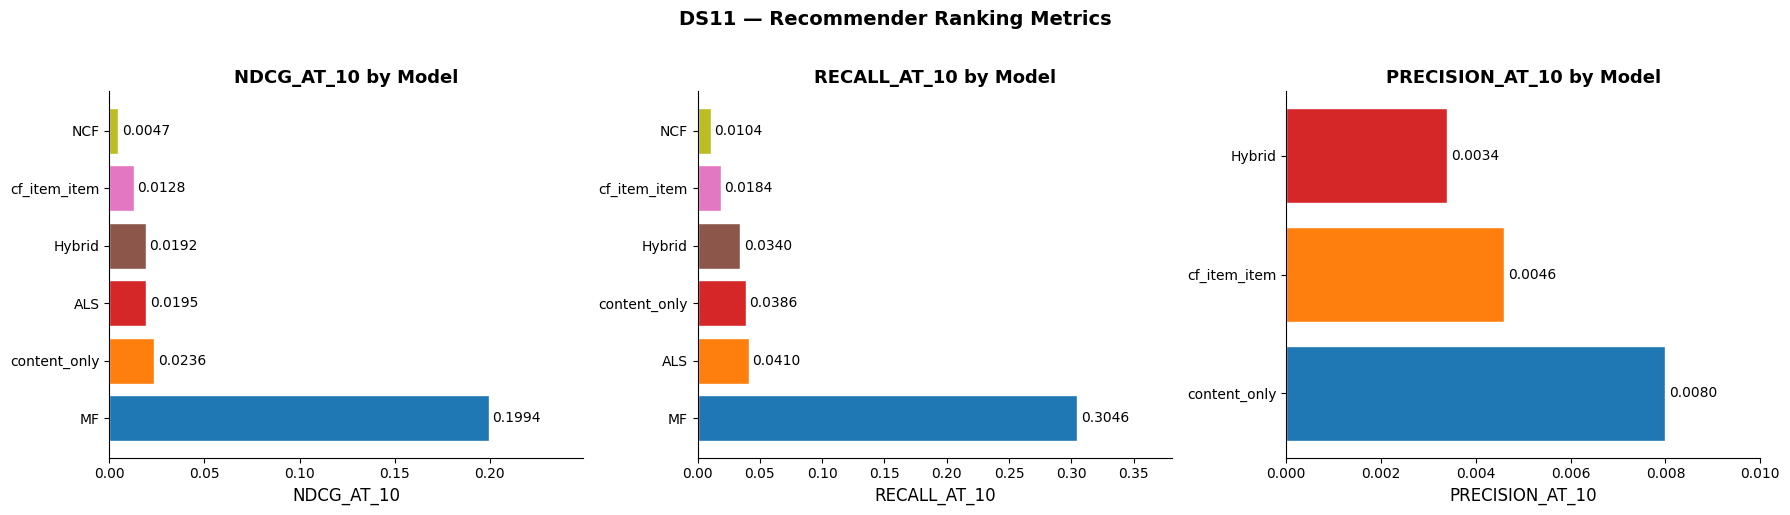

Saved -> e:\rs\outputs\phase11_rec_metrics.png


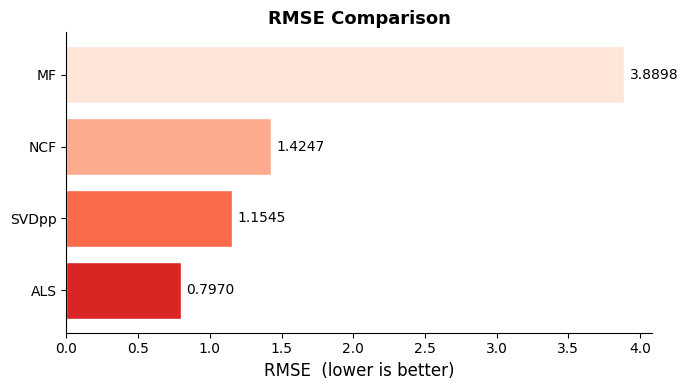

Saved -> e:\rs\outputs\phase11_rmse.png


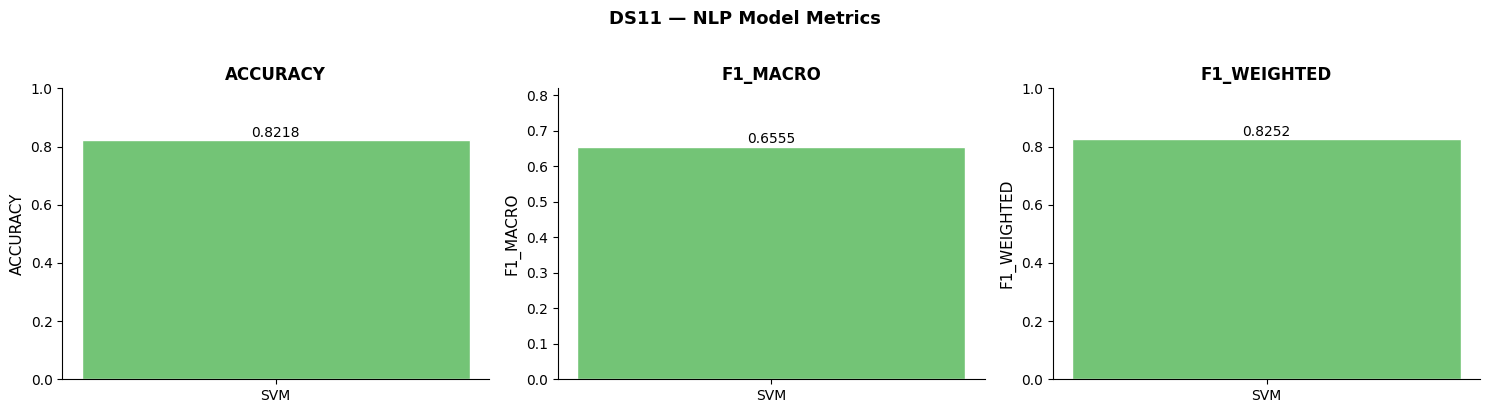

Saved -> e:\rs\outputs\phase11_nlp_metrics.png


In [16]:
# --- 11.3b: Bar charts for ranking metrics -----------------------------------
# Saves charts to outputs/ so they appear in the HTML export.

REC_PLOT_METRICS = [
    (c, c.upper()) for c in ['ndcg_at_10', 'recall_at_10', 'precision_at_10']
    if c in rec_df.columns
]
NLP_PLOT_METRICS = [
    (c, c.upper()) for c in ['accuracy', 'f1_macro', 'f1_weighted']
    if c in nlp_df.columns
]

# ---- Recommender ranking bar chart ----
if REC_PLOT_METRICS:
    n = len(REC_PLOT_METRICS)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]
    palette = plt.cm.tab10(np.linspace(0, 1, len(rec_df)))

    for ax, (col, label) in zip(axes, REC_PLOT_METRICS):
        data = pd.to_numeric(rec_df[col], errors='coerce').dropna().sort_values(ascending=False)
        bars = ax.barh(data.index, data.values,
                       color=palette[:len(data)], edgecolor='white')
        ax.set_xlabel(label, fontsize=12)
        ax.set_title(f'{label} by Model', fontsize=13, fontweight='bold')
        max_val = data.max() if not data.empty else 1
        ax.set_xlim(0, max_val * 1.25)
        for bar, val in zip(bars, data.values):
            ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('DS11 — Recommender Ranking Metrics', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    out_path = OUTPUTS_DIR / 'phase11_rec_metrics.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_path}')

# ---- RMSE bar chart (lower is better) ----
if 'rmse' in rec_df.columns:
    rmse_data = pd.to_numeric(rec_df['rmse'], errors='coerce').dropna().sort_values()
    if not rmse_data.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        reds = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(rmse_data)))
        bars = ax.barh(rmse_data.index, rmse_data.values,
                       color=reds, edgecolor='white')
        ax.set_xlabel('RMSE  (lower is better)', fontsize=12)
        ax.set_title('RMSE Comparison', fontsize=13, fontweight='bold')
        for bar, val in zip(bars, rmse_data.values):
            ax.text(val + rmse_data.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        out_path = OUTPUTS_DIR / 'phase11_rmse.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved -> {out_path}')

# ---- NLP classification bar chart ----
if NLP_PLOT_METRICS:
    n = len(NLP_PLOT_METRICS)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    greens = plt.cm.Greens(np.linspace(0.5, 0.85, len(nlp_df)))

    for ax, (col, label) in zip(axes, NLP_PLOT_METRICS):
        data = pd.to_numeric(nlp_df[col], errors='coerce').dropna().sort_values(ascending=False)
        bars = ax.bar(data.index, data.values, color=greens[:len(data)], edgecolor='white')
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'{label}', fontsize=12, fontweight='bold')
        ax.set_ylim(0, min(data.max() * 1.25, 1.0))
        for bar, val in zip(bars, data.values):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f'{val:.4f}', ha='center', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('DS11 — NLP Model Metrics', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    out_path = OUTPUTS_DIR / 'phase11_nlp_metrics.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_path}')


## 11.4 — Artifact Registry & Inline Display

**Cell 1** — Full artifact registry. Checks MLflow mlruns store, `outputs/`, and `models/`
for each artifact. Uses `pathlib.Path` throughout to avoid mixed forward/backslash issues
on Windows.

**Cell 2** — Displays key artifacts inline: images + text files.
Resolves each file from `outputs/` first, falls back to mlruns store.

| File | Run |
|------|-----|
| `confusion_matrix.png` | SVM |
| `classification_report.txt` | SVM |
| `phase6_umap_metrics.png` | MF / NCF |
| `final_top500_product_summary.csv` | T5_summary |


In [17]:
# --- Build run_id / exp_id lookups -----------------------------------------
run_id_lookup = runs_df.set_index('run_name')['run_id'].to_dict()
exp_id_lookup = runs_df.set_index('run_name')['experiment_id'].to_dict()

client = mlflow.tracking.MlflowClient(tracking_uri=MLFLOW_URI)

def get_artifacts(run_id):
    """Return list of FileInfo for a run, empty list on any error."""
    try:
        return client.list_artifacts(run_id)
    except Exception:
        return []

# Files each run is known to save to outputs/ (confirmed from outputs/ dir)
KNOWN_OUTPUTS = {
    'SVM'         : ['confusion_matrix.png', 'classification_report.txt'],
    'T5_summary'  : ['final_top500_product_summary.csv'],
    'MF'          : ['phase6_umap_metrics.png'],
    'NCF'         : ['phase6_umap_metrics.png'],
    'ALS'         : [],
    'SVDpp'       : [],
    'Hybrid'      : [],
    'content_only': [],
    'cf_item_item': [],
}

KNOWN_MODELS = {
    'MF'     : ['mf_model.pth'],
    'NCF'    : ['ncf_model.pth'],
    'ALS'    : ['als_model.npz', 'user_item_matrix.npz'],
    'SVDpp'  : ['svdpp_model.pkl'],
    'Hybrid' : ['hybrid_recommender.pkl', 'user_item_matrix.npz'],
    'SVM'    : ['svm_model.pkl', 'svm_vectorizer.pkl'],
}

# --- Build registry ---------------------------------------------------------
records = []
for _, row in runs_df.iterrows():
    run_id   = row['run_id']
    run_name = row['run_name']
    exp_id   = row['experiment_id']

    mlflow_arts = {a.path: a.file_size for a in get_artifacts(run_id)}
    all_names   = sorted(
        set(mlflow_arts)
        | set(KNOWN_OUTPUTS.get(run_name, []))
        | set(KNOWN_MODELS.get(run_name, []))
    )

    for name in all_names:
        mlruns_p  = Path(MLFLOW_URI) / 'mlruns' / exp_id / run_id / 'artifacts' / name
        outputs_p = OUTPUTS_DIR / name
        models_p  = MODELS_DIR  / name

        in_mlruns  = mlruns_p.exists()
        in_outputs = outputs_p.exists()
        in_models  = models_p.exists()

        if in_mlruns:
            location = 'mlruns'
            size     = mlflow_arts.get(name, mlruns_p.stat().st_size)
        elif in_outputs:
            location = 'outputs/'
            size     = outputs_p.stat().st_size
        elif in_models:
            location = 'models/'
            size     = models_p.stat().st_size
        else:
            # Artifact is recorded in MLflow metadata but not copied locally
            location = 'mlruns (not copied locally)'
            size     = mlflow_arts.get(name, 0)

        exists = in_mlruns or in_outputs or in_models

        records.append({
            'Run'      : run_name,
            'Artifact' : name,
            'Size (B)' : size,
            'Location' : location,
            'Exists'   : 'YES' if exists else 'NO',
        })

registry_df = pd.DataFrame(records)

def color_exists(col):
    return [
        'color: green; font-weight: bold' if v == 'YES'
        else 'color: red; font-weight: bold'
        for v in col
    ]

display(
    registry_df.style
    .apply(color_exists, subset=['Exists'])
    .set_caption('Artifact Registry -- All 9 Runs (mlruns + outputs/ + models/ lookup)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'), ('color', '#222'), ('padding', '10px 0')]},
        {'selector': 'th',
         'props': [('background-color', '#1a1a2e'), ('color', '#fff'),
                   ('padding', '8px 12px')]},
        {'selector': 'td',
         'props': [('padding', '7px 12px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)


Run,Artifact,Size (B),Location,Exists
Hybrid,hybrid_recommender.pkl,317275488,models/,YES
Hybrid,user_item_matrix.npz,339916,models/,YES
SVDpp,svdpp_model.pkl,41110411,models/,YES
ALS,als_model.npz,14561835,models/,YES
ALS,user_item_matrix.npz,339916,models/,YES
NCF,ncf_model.pth,29163156,models/,YES
NCF,phase6_umap_metrics.png,138209,outputs/,YES
MF,mf_model.pth,14788312,models/,YES
MF,phase6_umap_metrics.png,138209,outputs/,YES
T5_summary,final_top500_product_summary.csv,193466,outputs/,YES



[IMAGE] Confusion Matrix -- SVM Sentiment Classifier  [SVM]


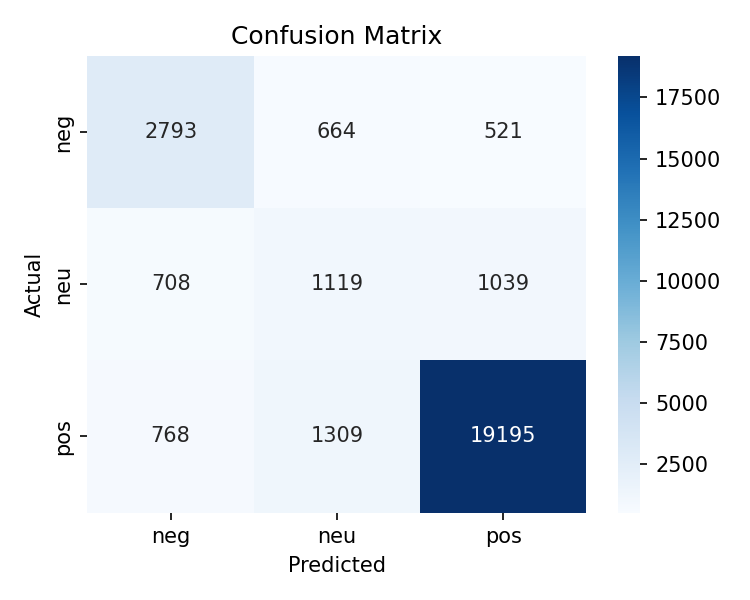


[IMAGE] UMAP + Metrics -- MF vs NCF (Phase 6)  [MF]


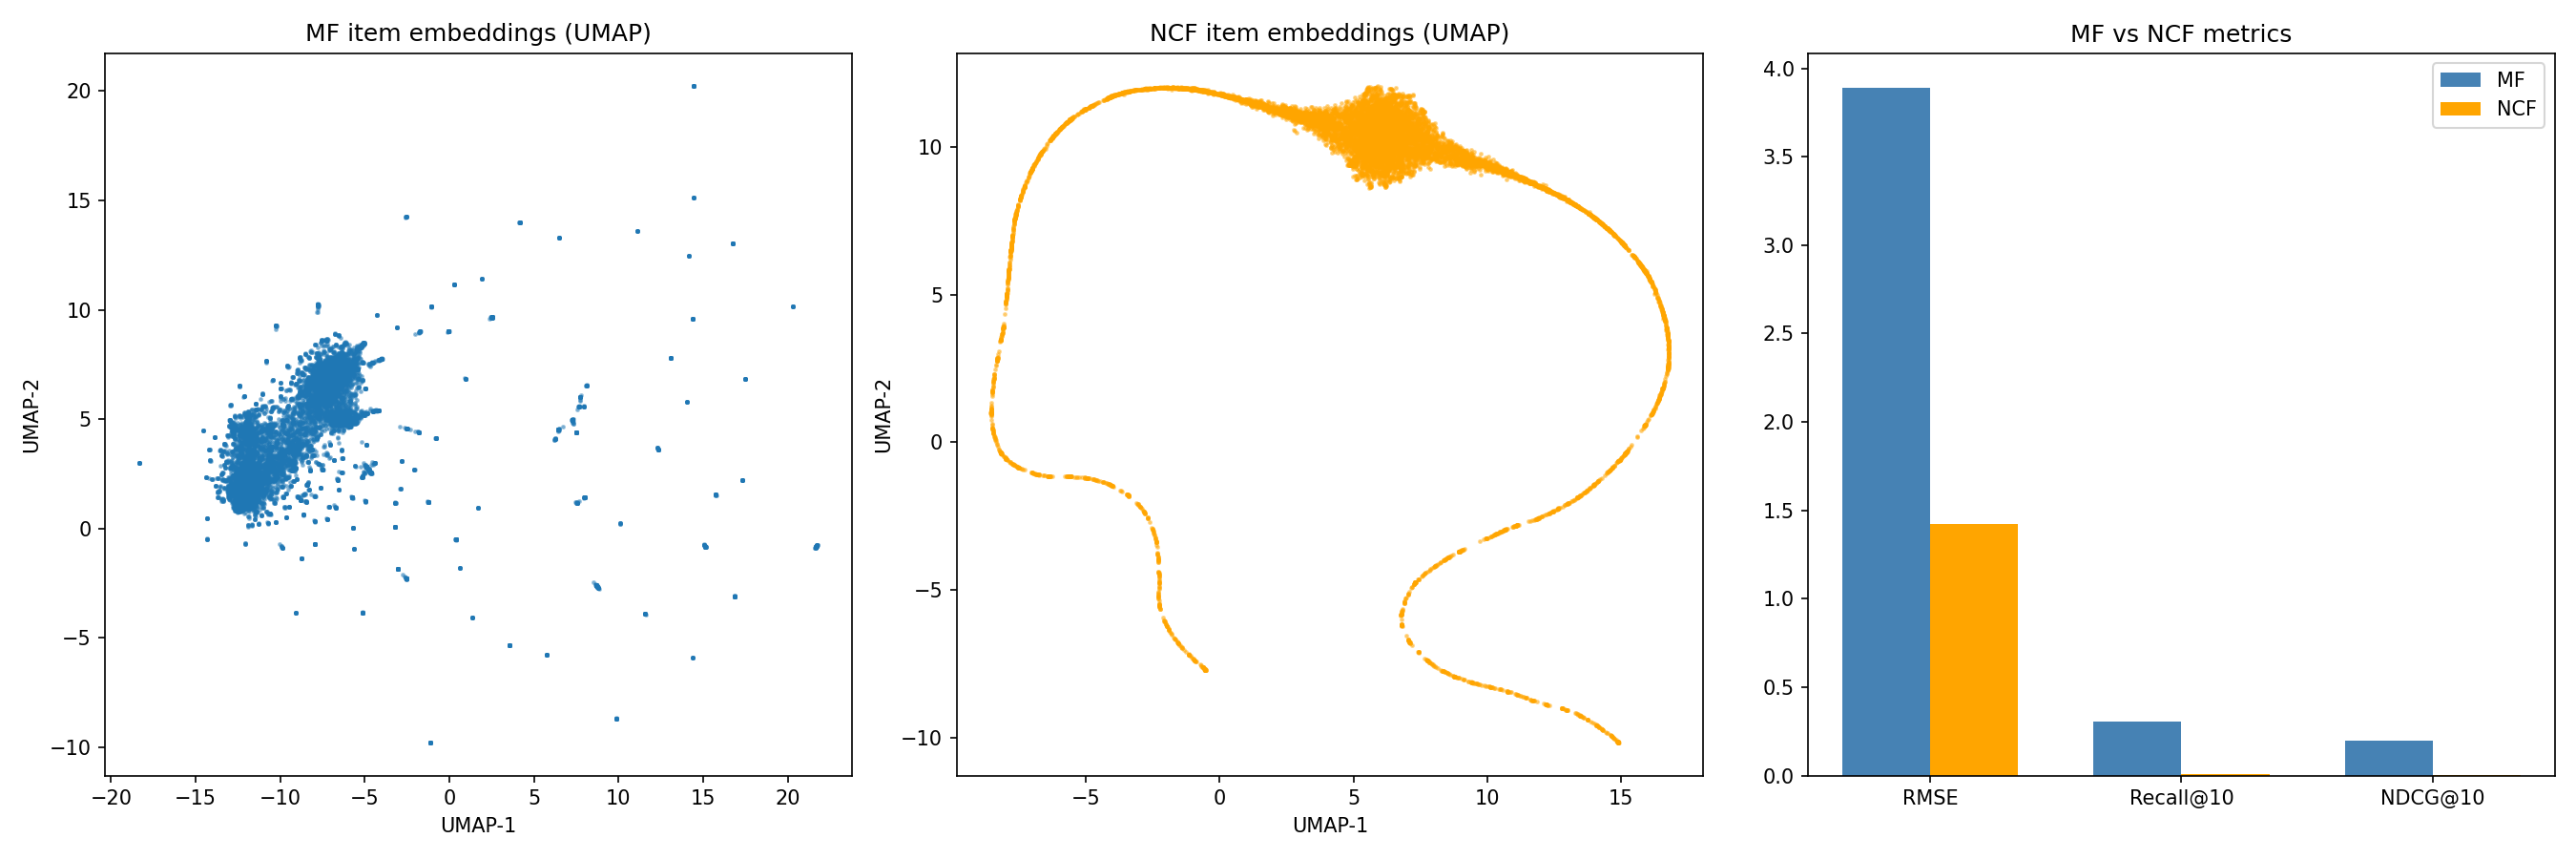


[TEXT] Classification Report -- SVM
              precision    recall  f1-score   support

    negative       0.65      0.70      0.68      3978
     neutral       0.36      0.39      0.38      2866
    positive       0.92      0.90      0.91     21272

    accuracy                           0.82     28116
   macro avg       0.65      0.66      0.66     28116
weighted avg       0.83      0.82      0.83     28116


[TEXT] T5 Summary -- Top 500 Products (first 20 rows)
asin,summary,avg_sentiment,n_reviews,avg_rating
B003LPTAYI,this is our rd pair of these my husband teenage son both use them my son s pair was recently damaged by one of our pets so this was purchased to replace his son . they are both very happy with their headphones the plastic headband is a single molded piece with the ear cups attached to each end of the headband . the sound quality is very good and even amazing given the low price however considering the overall design of the too tight headband and the cheap plastic 

In [18]:
# --- Cell 2: Display key artifacts inline ----------------------------------
# Resolves each file from outputs/ first, then falls back to mlruns store.

def resolve_artifact(run_name, filename):
    """Return pathlib.Path to artifact, preferring outputs/ then mlruns."""
    out_path = OUTPUTS_DIR / filename
    if out_path.exists():
        return out_path
    if run_name in run_id_lookup:
        mlruns_p = (
            Path(MLFLOW_URI) / 'mlruns'
            / exp_id_lookup[run_name]
            / run_id_lookup[run_name]
            / 'artifacts' / filename
        )
        if mlruns_p.exists():
            return mlruns_p
    return None

# --- Images -----------------------------------------------------------------
KEY_IMAGES = [
    ('SVM', 'confusion_matrix.png',    'Confusion Matrix -- SVM Sentiment Classifier'),
    ('MF',  'phase6_umap_metrics.png', 'UMAP + Metrics -- MF vs NCF (Phase 6)'),
]

for run_name, filename, caption in KEY_IMAGES:
    path = resolve_artifact(run_name, filename)
    if path:
        print(f'\n[IMAGE] {caption}  [{run_name}]')
        display(Image(filename=str(path), width=700))
    else:
        print(f'WARNING: Not found: {filename}  (run={run_name})')

# --- Text artifacts ---------------------------------------------------------
TEXT_ARTIFACTS = [
    ('SVM',        'classification_report.txt',
     'Classification Report -- SVM'),
    ('T5_summary', 'final_top500_product_summary.csv',
     'T5 Summary -- Top 500 Products (first 20 rows)'),
]

for run_name, filename, label in TEXT_ARTIFACTS:
    path = resolve_artifact(run_name, filename)
    if path:
        print(f'\n[TEXT] {label}')
        with open(path, encoding='utf-8') as f:
            if filename.endswith('.csv'):
                lines = f.readlines()
                print(''.join(lines[:21]))
                if len(lines) > 21:
                    print(f'  ... ({len(lines) - 21} more rows)')
            else:
                print(f.read())
    else:
        print(f'WARNING: Not found: {filename}  (run={run_name})')


## 11.5 — Summary & Export to HTML

In [19]:
# --- Final summary printout ------------------------------------------------
print('=' * 70)
print('PHASE 11 -- MLflow Experiment Report Summary')
print('=' * 70)
print(f'  Experiment        : {EXPERIMENT_NAME}')
print(f'  Tracking URI      : {MLFLOW_URI}')
print(f'  Runs loaded       : {len(runs_df)}')
print(f'  NLP runs          : {NLP_RUNS}')
print(f'  Recommender runs  : {RECOMMENDER_RUNS}')

print('\n  --- Recommender Best ---')
for col in rec_df.columns:
    num = pd.to_numeric(rec_df[col], errors='coerce')
    if num.notna().any():
        higher   = not any(k in col.lower() for k in ['rmse', 'loss', 'error'])
        best_idx = num.idxmax() if higher else num.idxmin()
        arrow    = '(higher better)' if higher else '(lower better)'
        print(f'  Best {col:<24} {arrow}: {best_idx} ({num[best_idx]:.4f})')

print('\n  --- NLP Best ---')
for col in nlp_df.columns:
    num = pd.to_numeric(nlp_df[col], errors='coerce')
    if num.notna().any():
        higher   = not any(k in col.lower() for k in ['rmse', 'loss', 'error', 'skipped'])
        best_idx = num.idxmax() if higher else num.idxmin()
        arrow    = '(higher better)' if higher else '(lower better)'
        print(f'  Best {col:<24} {arrow}: {best_idx} ({num[best_idx]:.4f})')

print('=' * 70)


PHASE 11 -- MLflow Experiment Report Summary
  Experiment        : DS11
  Tracking URI      : ../mlflow/
  Runs loaded       : 9
  NLP runs          : ['SVM', 'T5_summary']
  Recommender runs  : ['content_only', 'cf_item_item', 'MF', 'NCF', 'ALS', 'SVDpp', 'Hybrid']

  --- Recommender Best ---
  Best ndcg_at_10               (higher better): MF (0.1994)
  Best recall_at_10             (higher better): MF (0.3046)
  Best precision_at_10          (higher better): content_only (0.0080)
  Best rmse                     (lower better): ALS (0.7970)

  --- NLP Best ---
  Best avg_summary_length       (higher better): T5_summary (71.6100)
  Best n_skipped                (lower better): T5_summary (0.0000)
  Best n_summarized             (higher better): T5_summary (500.0000)
  Best f1_macro                 (higher better): SVM (0.6555)
  Best f1_weighted              (higher better): SVM (0.8252)
  Best accuracy                 (higher better): SVM (0.8218)


In [20]:
# --- Export notebook to HTML -----------------------------------------------
# IMPORTANT: Do NOT use --execute.
# Run all cells interactively first, then run THIS cell to convert.
# --execute would re-run all cells in a fresh kernel and recurse.

nb_src   = PROJECT_ROOT / 'src' / '11_mlflow_report.ipynb'
html_out = OUTPUTS_DIR  / 'mlflow_report.html'

cmd = [
    'jupyter', 'nbconvert',
    '--to', 'html',
    str(nb_src),
    '--output', str(html_out),
]

print('Running:', ' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    size_kb = html_out.stat().st_size / 1024
    print(f'\nOK -- HTML report exported: {html_out}')
    print(f'     File size: {size_kb:.1f} KB')
else:
    print(f'\nFAILED -- nbconvert returncode={result.returncode}')
    print('STDOUT:', result.stdout[:1000])
    print('STDERR:', result.stderr[:1000])
    print('\nRun manually from project root:')
    print('  jupyter nbconvert --to html src/11_mlflow_report.ipynb'
          ' --output outputs/mlflow_report.html')


Running: jupyter nbconvert --to html e:\rs\src\11_mlflow_report.ipynb --output e:\rs\outputs\mlflow_report.html

OK -- HTML report exported: e:\rs\outputs\mlflow_report.html
     File size: 789.9 KB


---
### Manual Export Command

From the **project root** (e.g. `e:\rs\`):

```bash
jupyter nbconvert --to html src/11_mlflow_report.ipynb \
    --output outputs/mlflow_report.html
```

> **Do NOT add `--execute`** — this would re-run all cells in a fresh
> kernel and trigger the nbconvert subprocess cell recursively.
